# Spark Preprocessing Pipeline (Notebook)

This notebook mirrors the script pipeline and keeps each stage in separate cells for interactive execution.

In [ ]:
import os
import pandas as pd
from pyspark.sql import SparkSession, DataFrame
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

from bi.config import (
    RAW_CSV, SPARK_PARQUET, OUTPUT_DIR, SPARK_CSV_ENCODING,
    SPARK_APP_NAME, SPARK_DRIVER_MEMORY, SPARK_SHUFFLE_PARTITIONS,
    SPARK_PYTHON, HADOOP_HOME, HADOOP_BIN, DROP_COLS, CORE_COLS, INT_COLS, DOUBLE_COLS,
    DELAY_MIN_MINUTES, DELAY_MAX_MINUTES,
)

In [2]:
os.environ['PYSPARK_PYTHON'] = SPARK_PYTHON
os.environ['PYSPARK_DRIVER_PYTHON'] = SPARK_PYTHON
os.environ['HADOOP_HOME'] = str(HADOOP_HOME)
os.environ['PATH'] = os.pathsep.join([str(HADOOP_BIN), os.environ.get('PATH', '')])

spark = (
    SparkSession.builder
    .appName(SPARK_APP_NAME)
    .config('spark.pyspark.python', SPARK_PYTHON)
    .config('spark.pyspark.driver.python', SPARK_PYTHON)
    .config('spark.executorEnv.PYSPARK_PYTHON', SPARK_PYTHON)
    .config('spark.driver.memory', SPARK_DRIVER_MEMORY)
    .config('spark.sql.shuffle.partitions', SPARK_SHUFFLE_PARTITIONS)
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print(f'Spark started: {SPARK_APP_NAME}')

Spark started: AirlineOnTime-Analytics


In [3]:
def load(spark: SparkSession) -> DataFrame:
    print(f'> Loading: {RAW_CSV}')
    df = (
        spark.read
        .option('header', 'true')
        .option('inferSchema', 'false')
        .option('nullValue', '')
        .option('encoding', SPARK_CSV_ENCODING)
        .csv(str(RAW_CSV))
    )
    print(f'  > Raw shape: {df.count():,} rows x {len(df.columns)} columns')
    return df


def drop_columns(df: DataFrame) -> DataFrame:
    return df.drop(*[c for c in DROP_COLS if c in df.columns])


def cast_types(df: DataFrame) -> DataFrame:
    for col in INT_COLS:
        if col in df.columns:
            df = df.withColumn(col, F.col(col).cast(DoubleType()).cast(IntegerType()))
    for col in DOUBLE_COLS:
        if col in df.columns:
            df = df.withColumn(col, F.col(col).cast(DoubleType()))
    return df


def clean(df: DataFrame) -> DataFrame:
    before = df.count()
    df = df.dropna(subset=[c for c in CORE_COLS if c in df.columns])
    df = df.filter(
        F.col('ArrDelay').isNull() |
        F.col('ArrDelay').between(DELAY_MIN_MINUTES, DELAY_MAX_MINUTES)
    ).filter(
        F.col('DepDelay').isNull() |
        F.col('DepDelay').between(DELAY_MIN_MINUTES, DELAY_MAX_MINUTES)
    )
    print(f'  > Removed {before - df.count():,} invalid rows')
    return df


def engineer_features(df: DataFrame) -> DataFrame:
    return (
        df
        .withColumn('Decade', (F.floor(F.col('Year') / 10) * 10).cast(IntegerType()))
        .withColumn(
            'Season',
            F.when(F.col('Month').isin(12, 1, 2), 1)
             .when(F.col('Month').isin(3, 4, 5), 2)
             .when(F.col('Month').isin(6, 7, 8), 3)
             .otherwise(4)
             .cast(IntegerType())
        )
        .withColumn('IsWeekend', F.when(F.col('DayOfWeek').isin(6, 7), 1).otherwise(0).cast(IntegerType()))
        .withColumn('DepHour', (F.col('CRSDepTime') / 100).cast(IntegerType()))
        .withColumn('IsDelayed', F.coalesce(F.col('ArrDel15'), F.lit(0)).cast(IntegerType()))
    )


def write_summary(df: DataFrame) -> None:
    total = df.count()
    null_exprs = [
        F.sum(F.when(F.col(c).isNull(), 1).otherwise(0)).alias(c)
        for c in df.columns
    ]
    null_counts = df.select(null_exprs).collect()[0]

    rows = [
        (c, total - null_counts[c], null_counts[c], round(null_counts[c] / total * 100, 2))
        for c in df.columns
    ]
    out = OUTPUT_DIR / 'summary_stats.csv'
    pd.DataFrame(rows, columns=['column', 'valid', 'missing', 'missing_pct']).to_csv(out, index=False)
    print(f'  > Summary stats -> {out}')

In [4]:
df = load(spark)
df = drop_columns(df)
df = cast_types(df)
df = clean(df)
df = engineer_features(df)

print(f'  > Final shape: {df.count():,} rows x {len(df.columns)} columns')
write_summary(df)

df.write.mode('overwrite').partitionBy('Year').parquet(str(SPARK_PARQUET))
print(f'  > Parquet saved -> {SPARK_PARQUET}')

> Loading: C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\data\airline_2m.csv
  > Raw shape: 2,000,000 rows x 109 columns
  > Removed 10 invalid rows
  > Final shape: 1,999,990 rows x 82 columns
  > Summary stats -> C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\summary_stats.csv
  > Parquet saved -> C:\uO\Academics\2026_02_SS\DTI_6287\dti6287\output\airline_cleaned_spark


In [ ]:
# Preview
preview_pdf = df.select('Year', 'Month', 'Origin', 'Dest', 'ArrDelay', 'DepDelay', 'IsDelayed').limit(20).toPandas()
preview_pdf

,Year,Month,Origin,Dest,ArrDelay,DepDelay,IsDelayed
0,1998,1,MSP,SLC,23.0,19.0,1
1,2009,5,MKE,MCO,0.0,-2.0,0
2,2013,6,GJT,DFW,-3.0,14.0,0
3,2010,8,LAX,DTW,-20.0,0.0,0
4,2006,1,EWR,CLT,32.0,51.0,1
5,1995,11,DFW,SHV,11.0,0.0,0
6,2006,8,BOS,CLE,2.0,-4.0,0
7,2019,6,ATL,CAE,214.0,221.0,1
8,2008,8,ORD,CLE,10.0,2.0,0
9,2018,2,MDW,DAL,29.0,16.0,1


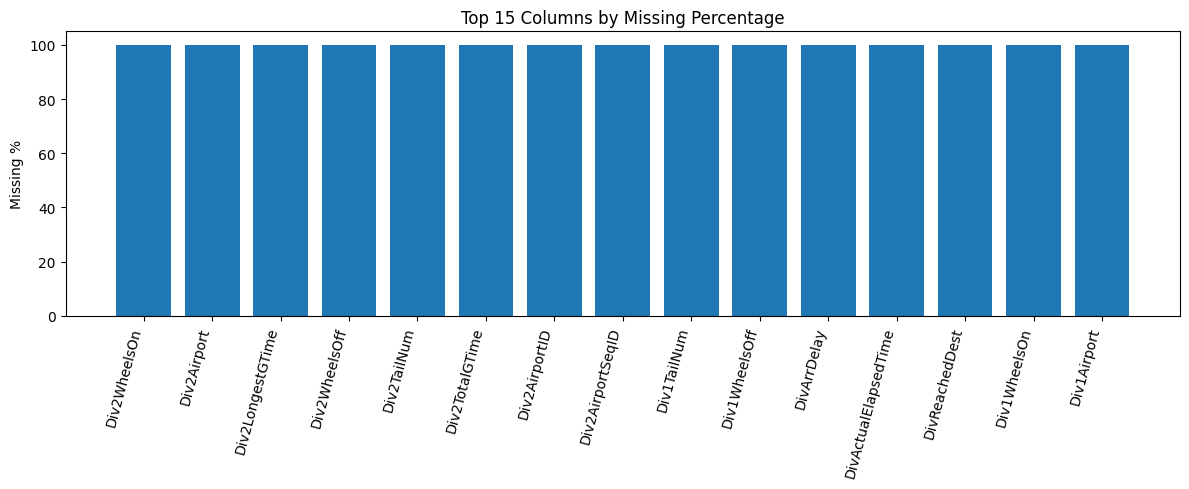

In [6]:
# Quick visual check of missingness
import matplotlib.pyplot as plt
summary_df = pd.read_csv(OUTPUT_DIR / 'summary_stats.csv')
top_missing = summary_df.sort_values('missing_pct', ascending=False).head(15)

plt.figure(figsize=(12, 5))
plt.bar(top_missing['column'], top_missing['missing_pct'])
plt.xticks(rotation=75, ha='right')
plt.ylabel('Missing %')
plt.title('Top 15 Columns by Missing Percentage')
plt.tight_layout()
plt.show()

In [7]:
# Stop Spark when done
spark.stop()